# Chatbot Answers — Word Cloud Analysis

Load queries and their 3 chatbot answers (OpenAI, Gemini, Perplexity), group them per query, clean the text, and render a word cloud for each.

## 1. Import Required Libraries

`wordcloud` gives full programmatic control: custom fonts, masks, color functions, stopword sets, and frequency filtering. Combined with `nltk` for linguistic stopwords and `re` for regex-based cleaning, we have end-to-end control over both logic and visuals.

In [39]:
%pip install -q wordcloud nltk

Note: you may need to restart the kernel to use updated packages.


In [40]:
import json
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud, STOPWORDS
import nltk

# Download English stopwords (only needed once)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

print("Libraries loaded.")

Libraries loaded.


## 2. Load and Inspect the Data

We load the three answer files (OpenAI / ChatGPT, Gemini, Perplexity) and the queries file, then build a flat DataFrame with one row per (query, provider, answer).

In [41]:
QUERIES_FILE = Path("data/queries.txt.txt")

# Map each version to its three answer files
VERSIONS = {
    "Baseline V0": {
        "ChatGPT":    Path("data/Baseline V0/chatgpt.answers.txt"),
        "Gemini":     Path("data/Baseline V0/gemini.answers.txt"),
        "Perplexity": Path("data/Baseline V0/perplexity.answers.txt"),
    },
    "V1": {
        "OpenAI":     Path("data/V1/openai.responses_c1.txt"),
        "Gemini":     Path("data/V1/gemini.responses_c1.txt"),
        "Perplexity": Path("data/V1/perplexity.responses_c1.txt"),
    },
    "V1+2": {
        "OpenAI":     Path("data/V1+2/openai.responses_c1+2.txt"),
        "Gemini":     Path("data/V1+2/gemini.responses_c1+2.txt"),
        "Perplexity": Path("data/V1+2/perplexity.responses_c1+2.txt"),
    },
    "V2": {
        "OpenAI":     Path("data/V2/openai.responses_c2.txt"),
        "Gemini":     Path("data/V2/gemini.responses_c2.txt"),
        "Perplexity": Path("data/V2/perplexity.responses_c2.txt"),
    },
}
VERSION_ORDER = list(VERSIONS.keys())

# --- Load queries ---
with open(QUERIES_FILE, encoding="utf-8") as f:
    raw_queries = json.load(f)
queries_map = {item["key"]: item["query"] for item in raw_queries["items"]}

# --- Load all versions ---
rows = []
for version, providers in VERSIONS.items():
    for provider, path in providers.items():
        if not path.exists():
            print(f"  [skip] {path}")
            continue
        with open(path, encoding="utf-8") as f:
            raw = json.load(f)
        for item in raw["items"]:
            query_key  = item.get("queryKey", "")
            query_text = queries_map.get(query_key, query_key)
            rows.append({
                "version":   version,
                "query_key": query_key,
                "query":     query_text,
                "provider":  provider,
                "answer":    item.get("text", ""),
            })

df = pd.DataFrame(rows)
print(f"Total rows  : {len(df)}")
print(f"Versions    : {df['version'].unique().tolist()}")
print(f"Queries     : {df['query_key'].nunique()}")
df.groupby("version").size().rename("rows")

Total rows  : 600
Versions    : ['Baseline V0', 'V1', 'V1+2', 'V2']
Queries     : 50


version
Baseline V0    150
V1             150
V1+2           150
V2             150
Name: rows, dtype: int64

## 3. Group and Concatenate Chatbot Answers per Query

For each query we join all three providers' answers into one big string, giving equal weight to every chatbot.

In [42]:
grouped = (
    df.groupby(["query_key", "query", "version"], sort=False)["answer"]
    .apply(lambda answers: " ".join(answers))
    .reset_index()
    .rename(columns={"answer": "combined_answer"})
)

grouped["version"] = pd.Categorical(grouped["version"], categories=VERSION_ORDER, ordered=True)
grouped = grouped.sort_values(["query_key", "version"]).reset_index(drop=True)

print(f"(query × version) pairs: {len(grouped)}")
grouped[["query", "version", "combined_answer"]].head(8)

(query × version) pairs: 200


,query,version,combined_answer
0,Where to find underwater drones for subsea ins...,Baseline V0,"Query: User query: In Switzerland, you can fin..."
1,Where to find underwater drones for subsea ins...,V1,"Query: User query: In Switzerland, you can fin..."
2,Where to find underwater drones for subsea ins...,V1+2,"Query: User query: In Switzerland, you can fin..."
3,Where to find underwater drones for subsea ins...,V2,"Query: User query: In Switzerland, you can fin..."
4,Where can I get wireless underwater communicat...,Baseline V0,"**Query:** User query: In **Switzerland**, you..."
5,Where can I get wireless underwater communicat...,V1,"Query: User query: In Switzerland, you can fin..."
6,Where can I get wireless underwater communicat...,V1+2,"Query: In Switzerland, several companies and r..."
7,Where can I get wireless underwater communicat...,V2,"Query: In Switzerland, you can find wireless u..."


## 4. Text Preprocessing

We strip:
- **Markdown** (`**bold**`, `*italic*`, `###` headers, `[text](url)` links)
- **Bare URLs** (`https://...`)
- **Digits and lone punctuation**
- **NLTK English stopwords** + a custom domain-specific extension (generic filler words that appear in AI-generated answers)

In [43]:
# ---------------------------------------------------------------------------
# Build the master stopword set
# ---------------------------------------------------------------------------
NLTK_STOPS = set(stopwords.words("english"))

# WordCloud's built-in set (articles, prepositions, etc.)
WC_STOPS = STOPWORDS

# Extra words that are common in AI-generated text but carry no semantic value
CUSTOM_STOPS = {
    # generic answer scaffolding
    "can", "also", "use", "used", "using", "well", "one", "two", "three",
    "many", "much", "often", "provide", "provides", "provided", "offering",
    "offer", "offers", "include", "includes", "including", "example",
    "examples", "typically", "usually", "generally", "such", "may", "might",
    "need", "needs", "required", "requires", "allow", "allows", "ensure",
    "ensures", "help", "helps", "make", "makes", "made", "want", "want",
    "note", "however", "therefore", "additionally", "furthermore", "also",
    "key", "important", "based", "specific", "especially", "various",
    "several", "certain", "different", "available", "designed", "provide",
    "system", "systems", "solution", "solutions", "technology", "technologies",
    "high", "low", "large", "small", "long", "short",
    # citation artefacts
    "query", "user", "summary", "sources", "source", "information",
    # numbers written out
    "first", "second", "third", "fourth", "fifth",
}

ALL_STOPS = NLTK_STOPS | WC_STOPS | CUSTOM_STOPS


# ---------------------------------------------------------------------------
# Cleaning function
# ---------------------------------------------------------------------------
def clean_text(text: str) -> str:
    # 1. Strip markdown image syntax  ![alt](url)
    text = re.sub(r"!\[.*?\]\(.*?\)", " ", text)
    # 2. Strip markdown links  [label](url)  — keep the label
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)
    # 3. Bare URLs
    text = re.sub(r"https?://\S+", " ", text)
    # 4. Markdown bold / italic  **text** / *text*
    text = re.sub(r"\*{1,3}([^*]+)\*{1,3}", r"\1", text)
    # 5. Markdown headers  ### title
    text = re.sub(r"^#{1,6}\s*", " ", text, flags=re.MULTILINE)
    # 6. HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # 7. Digits and lone punctuation / special chars
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # 8. Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip().lower()
    # 9. Remove stopwords
    tokens = [w for w in text.split() if w not in ALL_STOPS and len(w) > 2]
    return " ".join(tokens)


grouped["clean_text"] = grouped["combined_answer"].apply(clean_text)

# Quick sanity check
sample_idx = 0
print("Query    :", grouped.loc[sample_idx, "query"])
print("Clean    :", grouped.loc[sample_idx, "clean_text"][:300])

Query    : Where to find underwater drones for subsea inspection in Switzerland?
Clean    : switzerland find underwater drones subsea inspection specialized companies organizations tethys robotics swiss company eth zurich tethys underwater drone autonomous inspection modeling challenging underwater environments suitable hydropower offshore wind oil gas search rescue hydromea developer exra


## 5 & 6. Generate and Display a Word Cloud per Query

Each word cloud uses a distinct matplotlib colormap so queries are visually distinguishable at a glance. All WordCloud parameters are fully exposed for easy tweaking.

✓ Saved: wordcloud_outputs/wordcloud_Baseline_V0.png


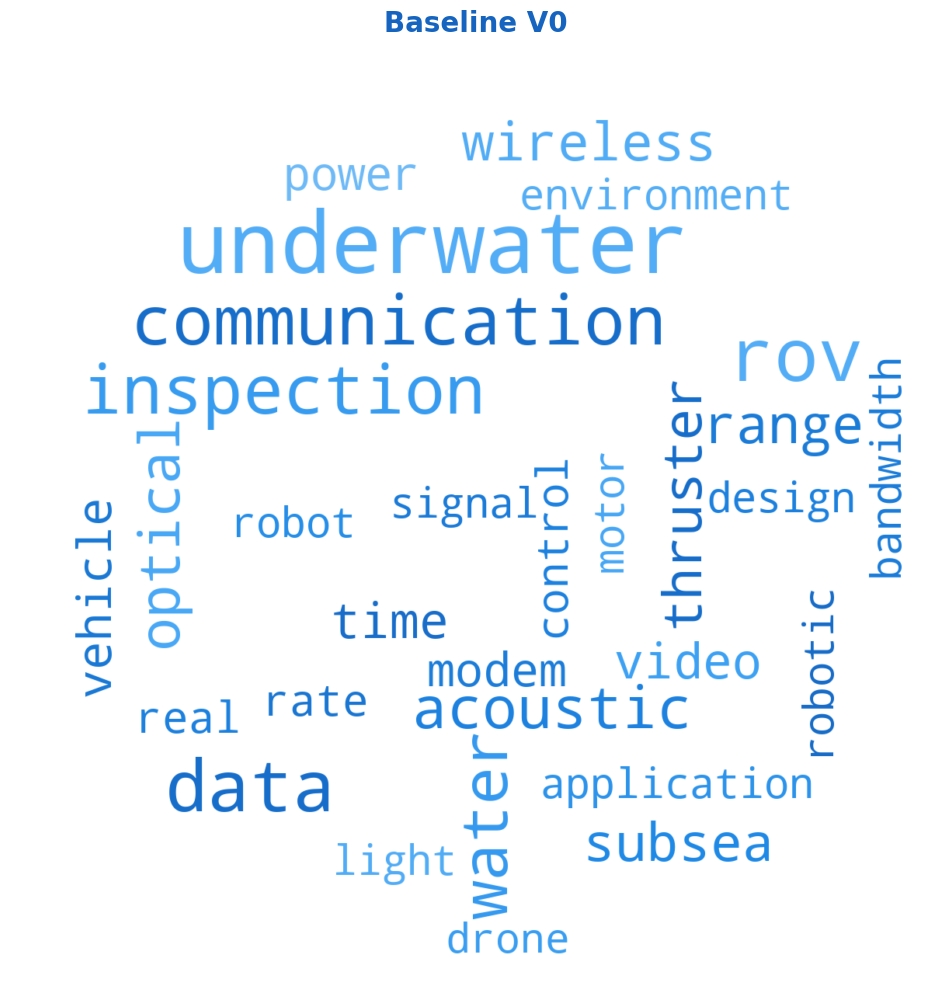

✓ Saved: wordcloud_outputs/wordcloud_V1.png


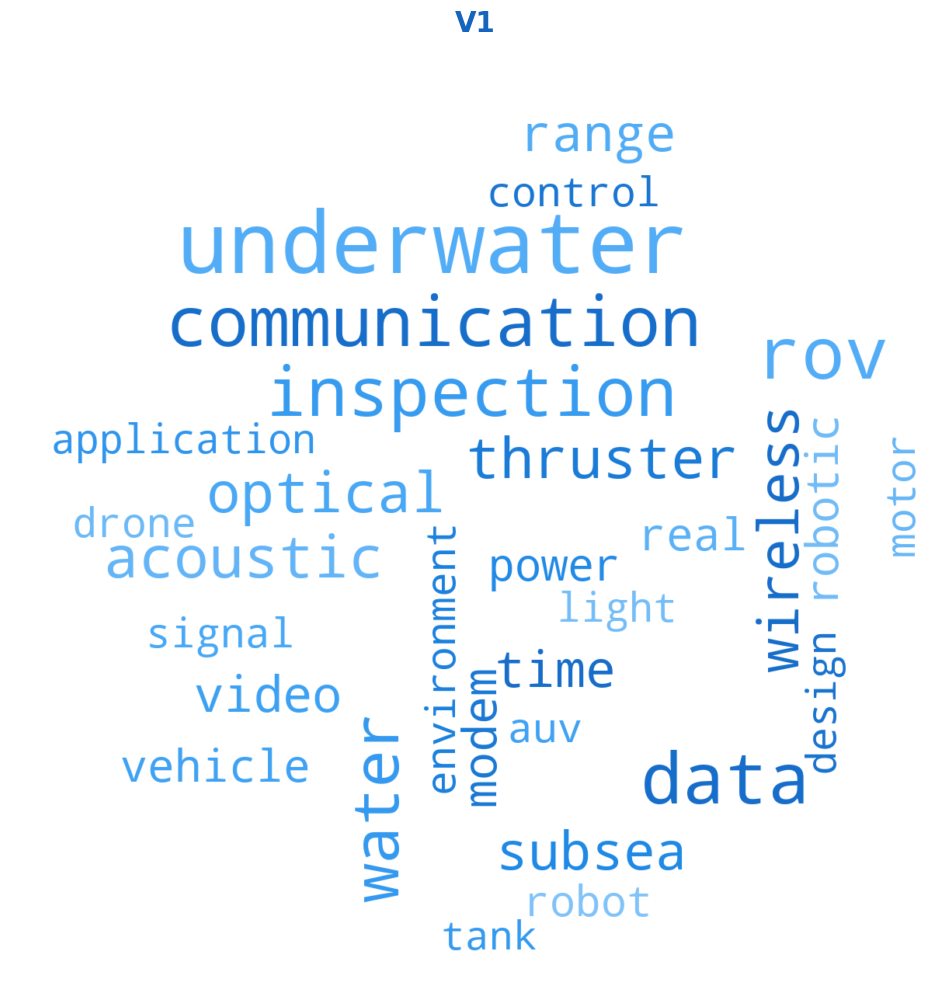

✓ Saved: wordcloud_outputs/wordcloud_V1_2.png


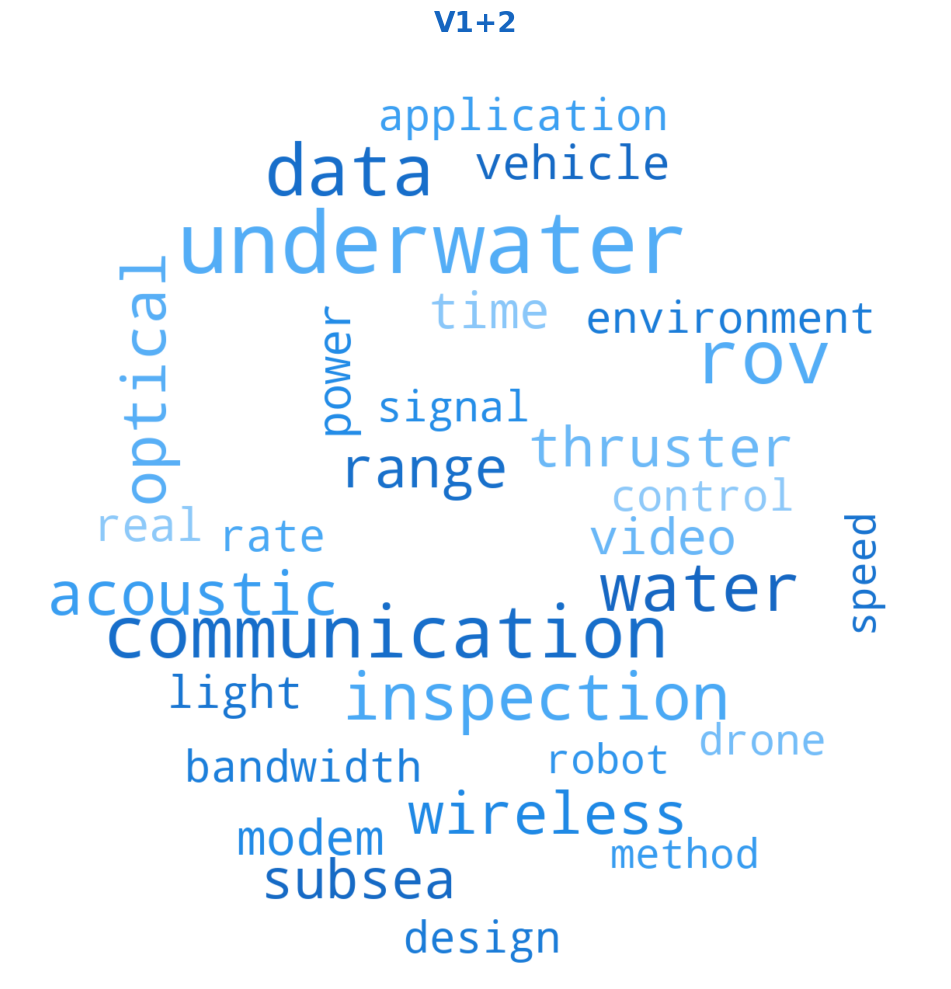

✓ Saved: wordcloud_outputs/wordcloud_V2.png


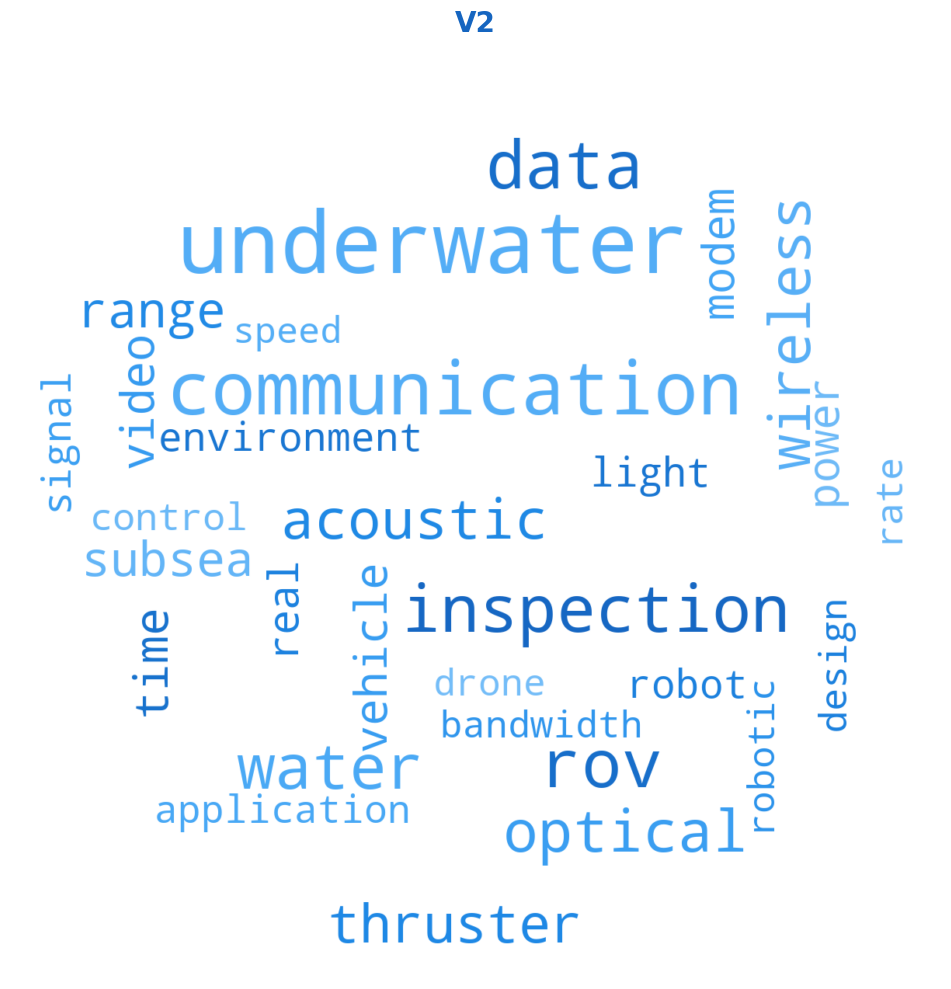


✓ Zipped: wordcloud_outputs.zip


In [45]:
import numpy as np
import shutil
from matplotlib.colors import LinearSegmentedColormap

# Output directory
OUTPUT_DIR = Path("wordcloud_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sphinx blue palette: white bg, blues only
SPHINX_CMAP = LinearSegmentedColormap.from_list(
    "sphinx_blue", ["#1565c0", "#1e88e5", "#42a5f5", "#90caf9"]
)

# Circular mask
_size = 1200
_y, _x = np.ogrid[:_size, :_size]
_c = _size // 2
circle_mask = np.full((_size, _size), 255, dtype=np.uint8)
circle_mask[(_x - _c) ** 2 + (_y - _c) ** 2 <= (_c - 4) ** 2] = 0

if "clean_text" not in grouped.columns:
    grouped["clean_text"] = grouped["combined_answer"].apply(clean_text)

version_texts = (
    grouped.groupby("version", observed=True)["clean_text"]
    .apply(lambda parts: " ".join(parts))
)

saved_files = []

for version in VERSION_ORDER:
    text = version_texts.get(version, "")
    if not text.strip():
        continue

    wc = WordCloud(
        mask             = circle_mask,
        background_color = "white",
        stopwords        = ALL_STOPS,
        max_words        = 30,
        min_font_size    = 9,
        max_font_size    = 110,
        collocations     = False,
        colormap         = SPHINX_CMAP,
        prefer_horizontal= 1.0,
        relative_scaling = 0.45,
        random_state     = 42,
    ).generate(text)

    fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(version, fontsize=20, fontweight="bold", color="#1565c0", pad=12)
    plt.tight_layout()

    # Save to disk
    filename = f"wordcloud_{version.replace('+', '_').replace(' ', '_')}.png"
    filepath = OUTPUT_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches="tight", facecolor="white")
    saved_files.append(filepath)
    print(f"✓ Saved: {filepath}")
    
    plt.show()

# Create zip archive
zip_path = Path("wordcloud_outputs.zip")
shutil.make_archive("wordcloud_outputs", "zip", OUTPUT_DIR.parent, OUTPUT_DIR.name)
print(f"\n✓ Zipped: {zip_path}")